# BEE 4750 Homework 2: Systems Modeling and Simulation

**Name**: Xindi Liu

**ID**: xl748

> **Due Date**
>
> Thursday, 09/25/25, 9:00pm

## Overview

### Instructions

-   Problem 1 asks you to draw a systems diagram and identify the type
    of a feedback.
-   Problem 2 asks you to model contaminant concentrations in a river
    and use simulation to compare the concentrations to a regulatory
    standard.
-   Problem 3 asks you to explore the implications of an ice-albedo
    feedback in the Earth’s climate system by understanding the
    equilibria of the modeled system and their stabilities.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/Desktop/Cornell_Courses/FA_25/BEE_4750/hw2-xindiliu`
   Installed InvertedIndices ───────────── v1.3.1
   Installed JpegTurbo_jll ─────────────── v3.1.3+0
   Installed WorkerUtilities ───────────── v1.6.1
   Installed SentinelArrays ────────────── v1.4.8
   Installed InlineStrings ─────────────── v1.4.5
   Installed Accessors ─────────────────── v0.1.42
   Installed Roots ─────────────────────── v2.2.10
   Installed DataFrames ────────────────── v1.8.0
   Installed WeakRefStrings ────────────── v1.4.2
   Installed PooledArrays ──────────────── v1.4.3
   Installed ConstructionBase ──────────── v1.6.0
   Installed DataValueInterfaces ───────── v1.0.0
   Installed Ghostscript_jll ───────────── v9.55.1+0
   Installed TableTraits ───────────────── v1.0.1
   Installed CompositionsBase ──────────── v0.1.2
   Installed InverseFunctions ──────────── v0.1.17
   Installed CommonSolve ───────────────── v0.2.4
   Installed IteratorInterfaceExtensions ─ v1.0.0
   Installed

In [2]:
using Plots
using LaTeXStrings
using CSV
using DataFrames
using Roots

## Problems (Total: 30 Points)

### Problem 1 (5 points)

Draw a systems diagram for the relationship between global mean
temperature, atmospheric CO<sub>2</sub> concentrations, and ocean
CO<sub>2</sub> concentrations. What are the signs of the interactions
between these components and why? What does this suggest about the
overall feedback between temperature and the ocean carbon cycle?

> **Tip**
>
> Think about Henry’s law for CO<sub>2</sub>.

The interaction between atmospheric CO₂ concentrations and global mean temperature is characterized by a positive feedback loop. An increase in atmospheric CO₂ enhances the greenhouse effect, leading to a rise in global mean temperature, which is also why it is a positive relationship. This warming, in turn, reduces the ocean's capacity to store CO₂, as the solubility of gases in water decreases with increasing temperature according to Henry's Law, so it is shown by a negative relationship from temperature to ocean CO₂ storage. Consequently, with the ocean's carbon sink efficiency diminished, more CO₂ is released into and remains in the atmosphere; again shown by a negative relationship from ocean CO₂ storage to atmospheric CO₂. This chain of effects creates a self-amplifying cycle: higher CO₂ levels cause warming, which reduces oceanic uptake, leading to even higher atmospheric CO₂ levels and further warming. This critical feedback loop accelerates climate change and is a fundamental concept in climate science.

### Problem 2 (15 points)

A river which flows at 10 km/d is receiving discharges of wastewater
contaminated with CRUD from two sources which are 15 km apart, as shown
in the Figure below. CRUD decays exponentially in the river at a rate of
0.36 $\mathrm{d}^{-1}$ and is deposited by the atmosphere along the
river at a rate of 54 kg/km/d. 

<figure>
  <img src="figures/river_diagram.png" 
       alt="Schematic of the river system in Problem 2" />
  <figcaption>Schematic of the river system in Problem 2</figcaption>
</figure>

#### Problem 2.1

Draw a systems diagram with the relevant control volume(s) denoted and
any relevant in/out-flows between these boxes. How did you decide how
many boxes were needed?

For this river inflow problem, the number of boxes was chosen based on changes in the river’s mass balance caused by point sources. Each point source introduces a sudden addition of water and pollutant, which changes the downstream concentration, so a separate box is needed after each discharge to capture this effect. In addition, along-stream processes such as first-order decay and deposition occur over distance, so each segment between point sources should be treated as a homogeneous control volume. Therefore, three boxes are sufficient: one for the upstream segment before any point sources, one for the middle segment between the two wastewater discharges (15 km long), and one for the downstream segment after the second discharge. This segmentation ensures that both the point-source additions and along-stream losses are accurately represented in the mass-balance equations.

#### Problem 2.2

Develop a model for the concentration of CRUD downriver by formulating
and solving the appropriate differential equation(s) analytically.

> **Tip**
>
> Formulate your model in terms of distance downriver, rather than
> leaving it in terms of time from discharge.

We formulate the model in terms of distance $x$ (km) downstream.  
Let $C(x)$ = pollutant concentration (kg/1000 m³), $Q$ = river discharge (m³/d),  
$v$ = velocity (km/d), $k$ = first-order decay constant (d$^{-1}$), and  
$r_{\text{dep}}$ = atmospheric deposition flux (kg/(km·d)).

The governing equation is:
\[
\frac{dC}{dx} = -\frac{k}{v} C + \frac{r_{\text{dep}}}{Q}.
\]

This is a linear ODE with solution:
\[
C(x) = C(0) e^{-\tfrac{k}{v}x} + \frac{r_{\text{dep}} v}{k Q} \Big( 1 - e^{-\tfrac{k}{v}x} \Big).
\]

\section*{Reach 1 (0--15 km)}

At $x=0$, upstream flow $Q_0 = 250{,}000$ m³/d with $C_0 = 0.5$ mixes with Waste A  
($Q_A = 40{,}000$ m³/d, $C_A = 9$). The mixed inflow is:
\[
C_1(0) = \frac{Q_0 C_0 + Q_A C_A}{Q_0 + Q_A} = 1.672,
\]
with
\[
Q_1 = 290{,}000 \ \text{m}^3/\text{d}.
\]

At $x=15$ km:
\[
C_1(15) = C_1(0) e^{-(k/v)L} + \frac{r_{\text{dep}} v}{k Q_1} \Big( 1 - e^{-(k/v)L} \Big),
\]
where $L = 15$ km. Numerically,
\[
C_1(15) \approx 3.13.
\]

\section*{Mixing at $x=15$ km}

Outflow from Reach 1 mixes with Waste B  
($Q_B = 60{,}000$ m³/d, $C_B = 7$):
\[
C_2(0) = \frac{Q_1 C_1(15) + Q_B C_B}{Q_1 + Q_B} \approx 3.80,
\]
with
\[
Q_2 = 350{,}000 \ \text{m}^3/\text{d}.
\]

\section*{Reach 2 (15--30 km)}

The solution is:
\[
C_2(x) = C_2(0) e^{-(k/v)(x-15)} + \frac{r_{\text{dep}} v}{k Q_2} \Big( 1 - e^{-(k/v)(x-15)} \Big).
\]

At $x=25$ km:
\[
C_2(25) \approx 3.94.
\]

As $x \to \infty$:
\[
C_{\infty} = \frac{r_{\text{dep}} v}{k Q_2} \approx 4.29.
\]


Continuous-time CRUD transport model (in distance $x$):

$$
\frac{dC}{dx} = -\frac{k}{v} C + \frac{r_{\mathrm{dep}}}{Q},
$$

where $C$ is concentration, $k$ is the decay rate, $v$ is the river velocity, 
$r_{\mathrm{dep}}$ is the deposition input, and $Q$ is discharge.

Forward Euler approximation (step size $\Delta x$):

$$
\frac{dC}{dx} \approx \frac{C_{n+1} - C_n}{\Delta x}.
$$

Substitute into the ODE:

$$
\frac{C_{n+1} - C_n}{\Delta x} = -\frac{k}{v} C_n + \frac{r_{\mathrm{dep}}}{Q}.
$$

Solve for $C_{n+1}$:

$$
C_{n+1} = C_n + \Delta x \left( -\frac{k}{v} C_n + \frac{r_{\mathrm{dep}}}{Q} \right).
$$

For $\Delta x = 1 \ \text{km}$:

$$
C_{n+1} = \left(1 - \frac{k}{v}\right) C_n + \frac{r_{\mathrm{dep}}}{Q}.
$$


#### Problem 2.3

Determine if the system in compliance with a regulatory limit of
$2.3\ \text{kg}/(1000 \text{m}^3)$. You can do this analytically or
computationally.

### Problem 3 (10 points)

In class, we discussed the ice-albedo feedback and its possible
influence on melting the hypothesized [“Snowball
Earth”](https://en.wikipedia.org/wiki/Snowball_Earth). In this problem,
we’ll introduce a simple model of the Earth’s energy balance with
includes this feedback and examine the stability of the climate.

This simple model of the energy balance (averaged over the entire
planet) is:

<span id="eq-climate">$$
\underbrace{C\frac{dT}{dt}}_{\text{change in heat}} = \underbrace{\frac{(1-\alpha)S}{4}}_{\text{incoming radiation}} - \underbrace{(A - BT)}_{\text{outgoing radiation}} + \underbrace{a\ln \left(\frac{[CO_2]}{[CO_2]_{PI}}\right)}_{\text{greenhouse effect}},
 \qquad(1)$$</span>

where:

-   $T$ is the Earth’s global mean temperature (in $^\circ\text{C}$);
-   $C$ is the heat capacity of the atmosphere and shallow ocean, taken
    to be $51\ \text{J}/\text{m}^2/^\circ\text{C}$;
-   $\alpha$ is the planetary albedo, or the fraction of incoming
    radiation reflected by the Earth, which has a present-day value of
    approximately 0.3;
-   $S$ is the solar constant, or the amount of solar radiation received
    by the Earth averaged over area, which has a present-day value of
    $1368\ \text{W}/\text{m}^2$ but during the Neoproteorozoic Era had a
    value of $1272\ \text{W}/\text{m}^2$ (this is divided by four
    because the Earth is a sphere but $S$ is the radiation captured by a
    disc with radius equal to that of the Earth);
-   $A$ and $B$ are coefficients from the linearization of outgoing
    radiation physics, and have corresponding values
    $B=-1.3\ \text{W}/\text{m}^2/^\circ\text{C}$ (estimated from a
    number of lines of evidence about the sensitivity of outgoing
    radiation to temperature; this is negative due to a sign convention
    about the direction of incoming vs. outgoing radiation) and
    $A=221.2\ \text{W}/\text{m}^2$ (estimated by assuming the
    pre-industrial temperature of $14^\circ\text{C}$ was stable without
    anthropogenic greenhouse gas emissions).

We will ignore the greenhouse effect term as we are considering the
Earth system well before humans were around.

#### Problem 3.1

Discretize the climate model
(<a href="#eq-climate" class="quarto-xref">Equation 1</a>) using forward
Euler integration and a time step of $\Delta t = 1$ yr.

Continuous-time climate model (ignoring greenhouse effect):

$$
C \frac{dT}{dt} = \frac{(1-\alpha)S}{4} - (A - B T)
$$

Forward Euler approximation:

$$
\frac{dT}{dt} \approx \frac{T_{n+1} - T_n}{\Delta t}
$$

Substitute into the ODE:

$$
C \frac{T_{n+1} - T_n}{\Delta t} = \frac{(1-\alpha)S}{4} - (A - B T_n)
$$

Solve for $T_{n+1}$:

$$
T_{n+1} = T_n + \frac{\Delta t}{C} \Big( \frac{(1-\alpha)S}{4} - A + B T_n \Big)
$$

For $\Delta t = 1$ year:

$$
T_{n+1} = \left(1 + \frac{B}{C}\right) T_n + \frac{1}{C} \left( \frac{(1-\alpha)S}{4} - A \right)
$$

Numerical values:

$$
C = 51 \ \text{J m}^{-2}\ ^\circ\text{C}^{-1}, \quad B = -1.3 \ \text{W m}^{-2}\ ^\circ\text{C}^{-1}
$$

Discrete update formula:

$$
T_{n+1} \approx 0.9745 \, T_n + 0.0196 \left( \frac{(1-\alpha)S}{4} - A \right)
$$

#### Problem 3.2

Rather than assuming a constant value for the albedo $\alpha$, we will
represent the ice-albedo feedback by letting $\alpha$ depend on $T$:

$$\alpha(T) = 
    \begin{cases} 
        \alpha_i & \quad \text{if } T \leq -10^\circ \text{C} \\
        \alpha_i + (\alpha_0 - \alpha_i)((T+10) / 20) & \quad \text{if } -10^\circ \text{C} \leq T \leq 10^\circ \text{C} \\
        \alpha_0 & \quad \text{if } T \geq 10^\circ \text{C}.
    \end{cases}$$

Let $\alpha_i = 0.5$ and $\alpha_0 = 0.3$. Simulate the simple climate
model using the Neoprotereozoic value of $S$ with temperature-varying
albedo for initial values of $T$ spanning
$-60^\circ\text{C} \leq T_0 \leq 30^\circ\text{C}$ over a period of 200
years. Plot the temperature trajectories. How many equilibria are there
and what are their stabilities?

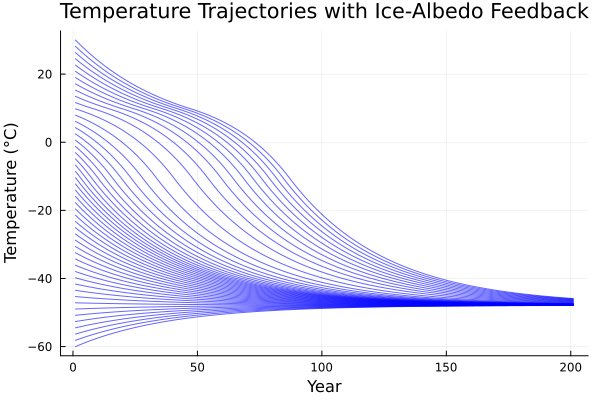

In [ ]:
# Parameters
C = 51.0           # Heat capacity (J/m²/°C)
A = 221.2          # Outgoing radiation parameter
B = -1.3           # Outgoing radiation sensitivity (W/m²/°C)
S = 1272.0         # Neoproterozoic solar constant (W/m²)
alpha_i = 0.5      # Ice-covered albedo
alpha_0 = 0.3      # Ice-free albedo
Δt = 1.0           # timestep in years
timesteps = 200    # number of years

# Albedo as a function of temperature
    if T <= -10
        return alpha_i
    elseif T >= 10
        return alpha_0
    else
        return alpha_i + (alpha_0 - alpha_i) * (T + 10)/20
    end
end

# Forward Euler update function
function update(T)
    return T + ( (1 - alpha(T))*S/4 - (A - B*T) ) * Δt / C
end

# Initial temperatures
T0 = range(-60, stop = 30, length = 50)

# Simulate trajectories
trajectories = []
for T_init in T0
    T = T_init
    traj = [T]
    for n in 1:timesteps
        T = update(T)
        push!(traj, T)
    end
    push!(trajectories, traj)
end

# Plot trajectories
using Plots
plot()
for traj in trajectories
    plot!(traj, color = :blue, alpha = 0.6, label = false)
end
xlabel!("Year")
ylabel!("Temperature (°C)")
title!("Temperature Trajectories with Ice-Albedo Feedback")

There is only one stable equilibrium at around -45°C, corresponding to the "Snowball Earth" state during the Neoproterozoic era. The solar constant S = 1272 W/m² is lower than the present-day value of 1368 W/m². This reduces the incoming solar radiation, making it harder for the Earth to escape a frozen state. The albedo function α(T) increases significantly when the temperature drops below −10°C, reflecting more sunlight and further cooling the planet. This positive feedback reinforces the cold state. All these reasons contribute to the stable equilibrium.

#### Problem 3.3

One might hypothesize that one cause for the transition from Snowball
Earth (the stable frozen equilibrium from Problem 3.2) was an increasing
amount of incoming solar radiation (as expressed by an increase in $S$).
Examine this hypothesis using our simple model. Is this factor enough to
cause the planet to warm to the pre-industrial temperature of
$14^\circ\text{C}$?

At equilibrium, the forward Euler climate model satisfies

$$
0 = \frac{(1-\alpha(T)) S}{4} - (A - B T),
$$

where $T$ is temperature in $^\circ C$, $S$ is the solar constant, $A$ and $B$ are outgoing radiation parameters, and $\alpha(T)$ is the temperature-dependent albedo. Solving for $T$ gives

$$
T = \frac{A - (1-\alpha(T)) S/4}{B}.
$$

For the warm state (ice-free, $\alpha \approx \alpha_0 = 0.3$) using the Neoproterozoic solar constant $S = 1272\ \text{W m}^{-2}$:

$$
\begin{aligned}
T_{\rm warm} &= \frac{A - (1-\alpha_0) S / 4}{B} \\
&= \frac{221.2 - 0.7 \times 1272 / 4}{-1.3} \\
&= \frac{221.2 - 222.6}{-1.3} \\
&= \frac{-1.4}{-1.3} \\
&\approx 1.08^\circ C.
\end{aligned}
$$

To reach the pre-industrial temperature $T = 14^\circ C$, the required solar constant would be

$$
S = \frac{4(A - B T)}{1-\alpha_0} 
= \frac{4(221.2 - (-1.3)(14))}{0.7} 
= \frac{957.6}{0.7} 
\approx 1368\ \text{W m}^{-2}.
$$

**Conclusion:** The Neoproterozoic solar constant ($1272\ \text{W m}^{-2}$) was too weak to give 14 °C. However, the gradual increase of the solar constant over Earth’s history (to ~1368 today) is, in principle, sufficient to allow such a transition. In practice, additional processes (like greenhouse gas buildup) were likely also involved, since solar luminosity increases on billion-year timescales, while Snowball Earth episodes ended much faster (millions of years).

## References

List any external references consulted, including classmates.

1. Used Julia Handbook for problem 2.3 for helping to understand the Dirichlet distribution. Distributions.jl. (2025, May 11). *Dirichlet*. In *Multivariate Distributions*. JuliaStats. Retrieved from https://juliastats.org/Distributions.jl/stable/multivariate/#Distributions.Dirichlet

2. Used ChatGPT for problems 1.3, 2.2, 2.4, mainly for searching syntax of Julia and helping understand how the coding language works, not for discussions and analysis of problems. OpenAI. (2025). ChatGPT (Feb 1 GPT-4 model) [Large language model]. https://chat.openai.com